In [1]:
import torch
from nrgpt_analysis import load_nrgpt

# using local model - you would have to train that one first (not provided here)
MODEL = "nrgpt_local"

# or use the model that can be downloaded from hf
# MODEL = "../nrgpt/out-OWT02_owt_best_configs/Best_OWT02_owt_best_configs_model=NRGPT_H_FF2W_embed=1536_depth=6_heads=12_LR=3e-05_minLR=None_minLrDiv=10.0_numIter=100000_exp_kko52p3j.pt"

model, tokenizer = load_nrgpt(MODEL)

Some weights of NRGPTForCausalLM were not initialized from the model checkpoint at ./nrgpt_local and are newly initialized: ['blocks.attn.heads.0.tril', 'blocks.attn.heads.1.tril', 'blocks.attn.heads.10.tril', 'blocks.attn.heads.11.tril', 'blocks.attn.heads.2.tril', 'blocks.attn.heads.3.tril', 'blocks.attn.heads.4.tril', 'blocks.attn.heads.5.tril', 'blocks.attn.heads.6.tril', 'blocks.attn.heads.7.tril', 'blocks.attn.heads.8.tril', 'blocks.attn.heads.9.tril', 'pos_idx']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
input_ids = tokenizer.encode("In recent years, researchers have discovered that ", return_tensors="pt")
with torch.no_grad():
    output = model.generate(input_ids, max_new_tokens=50)
print(tokenizer.decode(output[0]))

In recent years, researchers have discovered that 『N3SHINU1RR1BE2』 (Sigma) is often used in order to make a living. In this case, 『N3SHINU1RR1BE2』 is often used in order to make


In [3]:
from nrgpt_analysis import make_context, per_word_energies

ctx = make_context(model, tokenizer)
print(f"Block: {ctx.block.__class__.__name__}")
print(f"wte:   Embedding(num={ctx.wte.num_embeddings}, dim={ctx.wte.embedding_dim})")
print(f"wpe:   Embedding(num={ctx.wpe.num_embeddings}, dim={ctx.wpe.embedding_dim})")

records, _ = per_word_energies(
    "Researchers have made a shocking discovery.".split(), ctx, layers=(0,)
)
for r in records:
    print(r)

Block: BlockGrad_FF2W
wte:   Embedding(num=50304, dim=1536)
wpe:   Embedding(num=1024, dim=1536)
{'word': 'Researchers', 'n_bpe': 1, 'start': 0, 'E_attn_0': -322.63043212890625, 'E_ff_0': 286.841064453125, 'E_total_0': -35.78936767578125}
{'word': 'have', 'n_bpe': 1, 'start': 1, 'E_attn_0': -952.0647583007812, 'E_ff_0': 395.0389404296875, 'E_total_0': -557.0258178710938}
{'word': 'made', 'n_bpe': 1, 'start': 2, 'E_attn_0': -817.5899658203125, 'E_ff_0': 434.05633544921875, 'E_total_0': -383.53363037109375}
{'word': 'a', 'n_bpe': 1, 'start': 3, 'E_attn_0': -1322.64990234375, 'E_ff_0': 312.6081848144531, 'E_total_0': -1010.041748046875}
{'word': 'shocking', 'n_bpe': 1, 'start': 4, 'E_attn_0': -1699.300537109375, 'E_ff_0': 428.8775634765625, 'E_total_0': -1270.4229736328125}
{'word': 'discovery.', 'n_bpe': 2, 'start': 5, 'E_attn_0': -4046.268310546875, 'E_ff_0': 724.7570190429688, 'E_total_0': -3321.51123046875}


In [4]:
records, _ = per_word_energies(
    "Researchers have made a shocking shocking discovery and that discovery was shocking to a high degree.".split(),
    ctx, layers=(0,),
)
for r in records:
    print(r)

{'word': 'Researchers', 'n_bpe': 1, 'start': 0, 'E_attn_0': -322.63037109375, 'E_ff_0': 286.8410949707031, 'E_total_0': -35.789276123046875}
{'word': 'have', 'n_bpe': 1, 'start': 1, 'E_attn_0': -952.0648193359375, 'E_ff_0': 395.0389709472656, 'E_total_0': -557.02587890625}
{'word': 'made', 'n_bpe': 1, 'start': 2, 'E_attn_0': -817.5900268554688, 'E_ff_0': 434.0563049316406, 'E_total_0': -383.5337219238281}
{'word': 'a', 'n_bpe': 1, 'start': 3, 'E_attn_0': -1322.64990234375, 'E_ff_0': 312.6081848144531, 'E_total_0': -1010.041748046875}
{'word': 'shocking', 'n_bpe': 1, 'start': 4, 'E_attn_0': -1699.300537109375, 'E_ff_0': 428.87762451171875, 'E_total_0': -1270.4228515625}
{'word': 'shocking', 'n_bpe': 1, 'start': 5, 'E_attn_0': -1698.7886962890625, 'E_ff_0': 419.2405090332031, 'E_total_0': -1279.5482177734375}
{'word': 'discovery', 'n_bpe': 1, 'start': 6, 'E_attn_0': -1606.798828125, 'E_ff_0': 419.3245849609375, 'E_total_0': -1187.4742431640625}
{'word': 'and', 'n_bpe': 1, 'start': 7, 'E_

In [5]:
records, _ = per_word_energies(
    "Yesterday afternoon, the bus driver who the kids followed wondered about the location of a hotel.".split(),
    ctx, layers=(0,),
)
for r in records:
    print(r)

records, _ = per_word_energies(
    "Yesterday, the bus driver who the kids followed wondered about the location of a hotel.".split(),
    ctx, layers=(0,),
)
for r in records:
    print(r)

{'word': 'Yesterday', 'n_bpe': 1, 'start': 0, 'E_attn_0': -324.8057861328125, 'E_ff_0': 335.183837890625, 'E_total_0': 10.3780517578125}
{'word': 'afternoon,', 'n_bpe': 2, 'start': 1, 'E_attn_0': -3344.860107421875, 'E_ff_0': 669.13720703125, 'E_total_0': -2675.72265625}
{'word': 'the', 'n_bpe': 1, 'start': 3, 'E_attn_0': -2495.80126953125, 'E_ff_0': 348.0444641113281, 'E_total_0': -2147.7568359375}
{'word': 'bus', 'n_bpe': 1, 'start': 4, 'E_attn_0': -3056.54931640625, 'E_ff_0': 395.2027587890625, 'E_total_0': -2661.3466796875}
{'word': 'driver', 'n_bpe': 1, 'start': 5, 'E_attn_0': -2897.8701171875, 'E_ff_0': 367.9349670410156, 'E_total_0': -2529.93505859375}
{'word': 'who', 'n_bpe': 1, 'start': 6, 'E_attn_0': -2850.920166015625, 'E_ff_0': 509.6289978027344, 'E_total_0': -2341.291259765625}
{'word': 'the', 'n_bpe': 1, 'start': 7, 'E_attn_0': -2482.051025390625, 'E_ff_0': 341.2950439453125, 'E_total_0': -2140.755859375}
{'word': 'kids', 'n_bpe': 1, 'start': 8, 'E_attn_0': -2859.74658203

In [6]:
import pandas as pd

df = pd.read_csv("psych_data/memory-for-prediction/psycholinguistic-phenomena/data/Staub2010_loc_control_orc.csv")
print(f"{len(df)} rows, types: {df['type'].value_counts().to_dict()}")

48 rows, types: {'SR': 24, 'OR': 24}


Some weights of NRGPTForCausalLM were not initialized from the model checkpoint at ./nrgpt_local and are newly initialized: ['blocks.attn.heads.0.tril', 'blocks.attn.heads.1.tril', 'blocks.attn.heads.10.tril', 'blocks.attn.heads.11.tril', 'blocks.attn.heads.2.tril', 'blocks.attn.heads.3.tril', 'blocks.attn.heads.4.tril', 'blocks.attn.heads.5.tril', 'blocks.attn.heads.6.tril', 'blocks.attn.heads.7.tril', 'blocks.attn.heads.8.tril', 'blocks.attn.heads.9.tril', 'pos_idx']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[(1, 3, 'firemen'), (3, 4, 'that'), (4, 5, 'the'), (5, 6, 'residents'), (6, 7, 'called'), (7, 8, 'attacked'), (8, 9, 'the'), (9, 10, 'house'), (10, 11, 'with'), (11, 14, 'high-powered'), (14, 16, 'hoses')]
        word |        L1        L2        L3        L4        L5        L6
--------------------------------------------------------------------------
     firemen |   1805.97   -833.23  -1216.92  -1464.26  -1534.82  -1958.68
        that |    619.52   -523.12   -690.10   -770.79   -806.92  -1311.91
         the |    757.61   -514.64   -714.71   -811.51   -840.52  -1504.12
   residents |    740.18   -470.41   -654.53   -747.82   -777.49  -1412.28
      called |    746.84   -529.41   -686.08   -792.61   -814.19  -1428.79
    attacked |    686.57   -517.11   -662.19   -778.61   -843.18  -1480.52
         the |    755.28   -492.44   -691.30   -794.63   -851.61  -1861.95
       house |    840.66   -443.55   -610.45   -695.68   -735.63  -1044.89
        with |    648.36   -507.91   -657.43

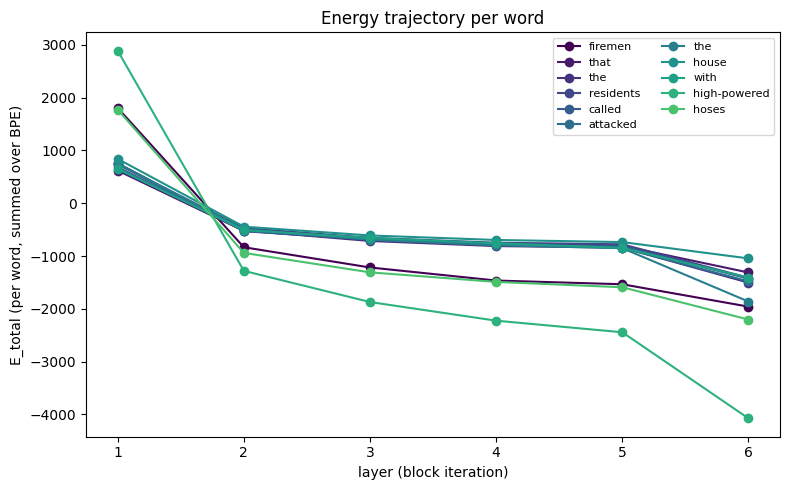

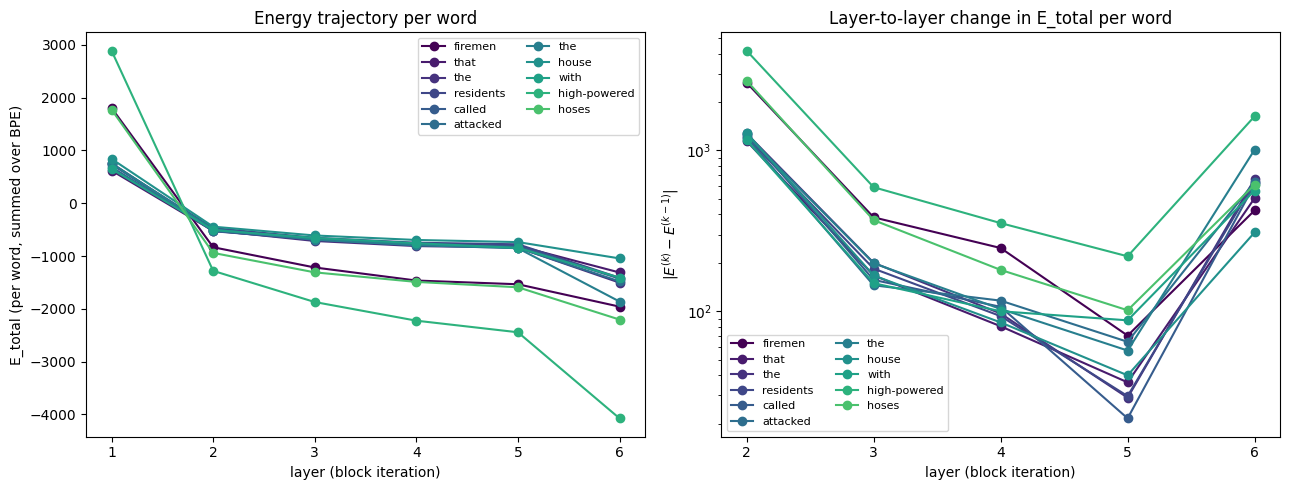

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from nrgpt_analysis import load_nrgpt, make_context, per_word_energies
cmap = plt.cm.viridis(np.linspace(0, 1, len(records)))

model, tokenizer = load_nrgpt("nrgpt_local")
ctx = make_context(model, tokenizer)

words = "The firemen that the residents called attacked the house with high-powered hoses".split()
layers = (1, 2, 3, 4, 5, 6)

# E_total per word (summed over its BPE span) at every layer.
records, ranges = per_word_energies(words, ctx, layers=layers)

records = records[1:]

ranges = ranges[1:]

print(ranges)

# Stack into arrays of shape (n_words, n_layers).
E = np.array([[r[f"E_total_{k}"] for k in layers] for r in records])
dE = np.abs(np.diff(E, axis=1))  # shape (n_words, n_layers - 1)

# Print per-word trajectory and layer-to-layer change.
header = "word".rjust(12) + " | " + " ".join(f"L{k}".rjust(9) for k in layers)
print(header)
print("-" * len(header))
for r, row in zip(records, E):
    print(f"{r['word']:>12s} | " + " ".join(f"{v:9.2f}" for v in row))

print()
header2 = "word".rjust(12) + " | " + " ".join(
    f"L{a}->L{b}".rjust(9) for a, b in zip(layers[:-1], layers[1:])
)
print(header2)
print("-" * len(header2))
for r, row in zip(records, dE):
    print(f"{r['word']:>12s} | " + " ".join(f"{v:9.2f}" for v in row))

fig, axes = plt.subplots(1, 1, figsize=(8, 5))

for i, (r, row) in enumerate(zip(records, E)):
    axes.plot(layers, row, marker="o", color=cmap[i], label=r["word"])
axes.set_xlabel("layer (block iteration)")
axes.set_ylabel("E_total (per word, summed over BPE)")
axes.set_title("Energy trajectory per word")
axes.legend(loc="best", fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('energy_descent.png', bbox_inches='tight')
plt.show()

# Plot: trajectories on the left, layer-to-layer changes on the right.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))


for i, (r, row) in enumerate(zip(records, E)):
    axes[0].plot(layers, row, marker="o", color=cmap[i], label=r["word"])
axes[0].set_xlabel("layer (block iteration)")
axes[0].set_ylabel("E_total (per word, summed over BPE)")
axes[0].set_title("Energy trajectory per word")
axes[0].legend(loc="best", fontsize=8, ncol=2)

for i, (r, row) in enumerate(zip(records, dE)):
    axes[1].plot(layers[1:], row, marker="o", color=cmap[i], label=r["word"])
plt.xticks([2, 3, 4, 5, 6])
axes[1].set_xlabel("layer (block iteration)")
axes[1].set_ylabel(r"$|E^{(k)} - E^{(k-1)}|$")
axes[1].set_title("Layer-to-layer change in E_total per word")
axes[1].set_yscale("log")
axes[1].legend(loc="best", fontsize=8, ncol=2)

plt.tight_layout()
#plt.savefig('energy_descent.png', bbox_inches='tight')
plt.show()

#plt.savefig('energy_descent.png', bbox_inches='tight')


Number of tokens:  1


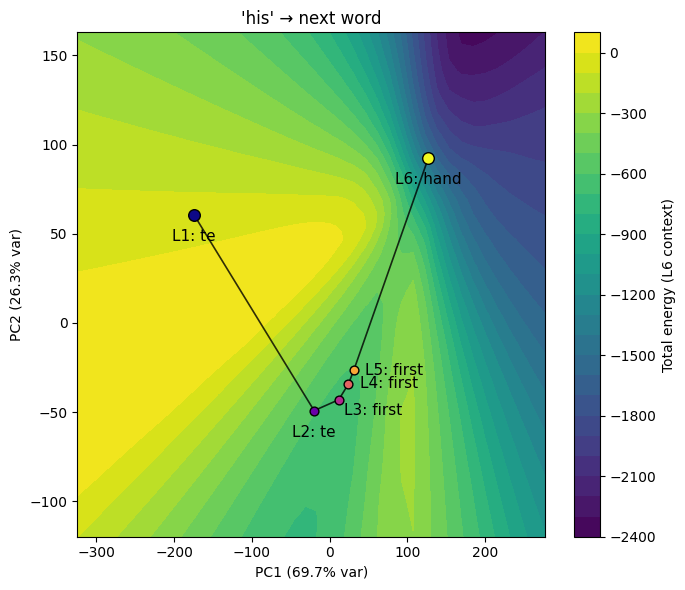

In [8]:
from nrgpt_analysis import plot_energy_landscape_2d

_, ax = plt.subplots(1, 1, figsize=(7, 6))

words = "He unlocked the door with his key and entered.".split() #He unlocked the door with his key and entered.
crit = "key"
crit_idx = next(i for i, w in enumerate(words) if w.rstrip(",.!?;:") == crit)

print("Number of tokens: ", per_word_energies(words, ctx, layers=(0,))[0][crit_idx-1]['n_bpe']) # should be just one token

plot_energy_landscape_2d(words, ctx, word_idx=crit_idx - 1, start_step=1, ax=ax, show_predictions=True)
ax.set_title(f"'{words[crit_idx - 1]}' → next word")

plt.tight_layout()
plt.savefig('energy_example.png', bbox_inches='tight')
plt.show()

Number of tokens:  1
Number of tokens:  1


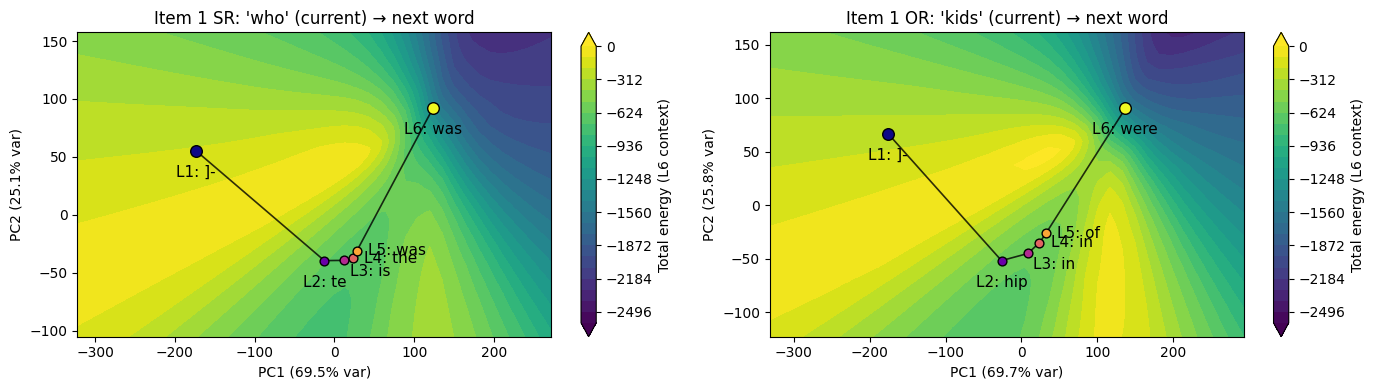

In [9]:
from nrgpt_analysis import plot_energy_landscape_2d

item_id = 1


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, cond in zip(axes, ["SR", "OR"]):
    row = df[(df["id"] == item_id) & (df["type"] == cond)].iloc[0]
    words = row["sentence"].split()
    crit = row["crit"]
    crit_idx = next(i for i, w in enumerate(words) if w.rstrip(",.!?;:") == crit)
    print("Number of tokens: ", per_word_energies(words, ctx, layers=(0,))[0][crit_idx-1]['n_bpe']) # should be just one token

    plot_energy_landscape_2d(words, ctx, word_idx=crit_idx - 1, start_step=1, ax=ax, show_predictions=True, vmin=-2600, vmax=0)
    ax.set_title(f"Item {item_id} {cond}: '{words[crit_idx - 1]}' (current) → next word")

plt.tight_layout()
plt.savefig('energy_relclause_example.png', bbox_inches='tight')
plt.show()

In [8]:
# check that split into <s> + H = E_attn

from nrgpt_analysis import per_word_attention_stats

e_recs, _ = per_word_energies(words, ctx, layers=(5,))
a_recs, _ = per_word_attention_stats(words, ctx, layers=(5,))
for er, ar in zip(e_recs, a_recs):
      rhs = -(ar["expected_score_5"] + ar["entropy_5"])
      print(f"{er['word']:>12s}  E_attn={er['E_attn_5']:.4f}  -(<s>+H)={rhs:.4f}")


         The  E_attn=-1102.7615  -(<s>+H)=-1102.7615
     firemen  E_attn=-2041.9966  -(<s>+H)=-2041.9965
        that  E_attn=-1056.2819  -(<s>+H)=-1056.2818
         the  E_attn=-1056.4984  -(<s>+H)=-1056.4984
   residents  E_attn=-1058.8007  -(<s>+H)=-1058.8007
      called  E_attn=-1067.8544  -(<s>+H)=-1067.8543
    attacked  E_attn=-1104.6683  -(<s>+H)=-1104.6683
         the  E_attn=-1057.2584  -(<s>+H)=-1057.2583
       house  E_attn=-992.9265  -(<s>+H)=-992.9264
        with  E_attn=-1057.8973  -(<s>+H)=-1057.8973
high-powered  E_attn=-3322.9277  -(<s>+H)=-3322.9278
       hoses  E_attn=-2150.9199  -(<s>+H)=-2150.9197


In [9]:
from nrgpt_analysis import (
    per_word_energies,
    per_word_predictive_energies,
    per_word_predictive_conditional_energies,
    per_word_surprisal,
)


def critical_word_index(words, crit):
    """Index of `crit` in `words`, matching after stripping trailing punctuation."""
    for i, w in enumerate(words):
        if w.rstrip(",.!?;:") == crit:
            return i
    return None


rows = []
for _, r in df.iterrows():
    words = r["sentence"].split()
    i = critical_word_index(words, r["crit"])
    if i is None:
        print(f"  miss: id={r['id']} type={r['type']} crit='{r['crit']}'")
        continue

    e_rec, _    = per_word_energies(words, ctx)
    pred_rec, _ = per_word_predictive_energies(words, ctx)
    tok_rec, _  = per_word_predictive_conditional_energies(words, ctx)
    surps, _    = per_word_surprisal(words, ctx)

    rows.append({
        "id": r["id"], "type": r["type"], "crit": r["crit"],
        **e_rec[i], **pred_rec[i], **tok_rec[i],
        "surprisal": surps[i],
    })

results_df = pd.DataFrame(rows)
print(results_df.shape)
results_df.head()

(48, 140)


,id,type,crit,word,n_bpe,start,E_attn_0,E_ff_0,E_total_0,E_attn_1,...,E_attn_token_sum_5,E_ff_token_sum_5,E_total_token_sum_5,E_attn_token_6,E_ff_token_6,E_total_token_6,E_attn_token_sum_6,E_ff_token_sum_6,E_total_token_sum_6,surprisal
0,1,SR,followed,followed,1,9,-2813.026855,359.437378,-2453.589355,1023.959473,...,-286.514903,367.363098,80.848195,-18.517120,367.363098,348.845978,-18.517120,367.363098,348.845978,7.043648
1,1,OR,followed,followed,1,9,-2815.000488,359.437378,-2455.562988,1025.856445,...,-286.851338,367.363098,80.511760,-19.899631,367.363098,347.463467,-19.899631,367.363098,347.463467,9.063010
2,2,SR,distracted,distracted,1,8,-2768.246338,543.474731,-2224.771484,1019.408447,...,197.754255,519.206177,716.960432,-275.715952,519.206177,243.490225,-275.715952,519.206177,243.490225,14.098034
3,2,OR,distracted,distracted,1,9,-2757.378174,517.401794,-2239.976318,1040.064087,...,191.090209,543.474792,734.565002,-277.685291,543.474792,265.789501,-277.685291,543.474792,265.789501,13.817634
4,3,SR,woke,woke,1,8,-2767.584229,484.376404,-2283.207764,1065.624146,...,93.321090,469.818787,563.139876,-344.947981,469.818787,124.870806,-344.947981,469.818787,124.870806,7.242990


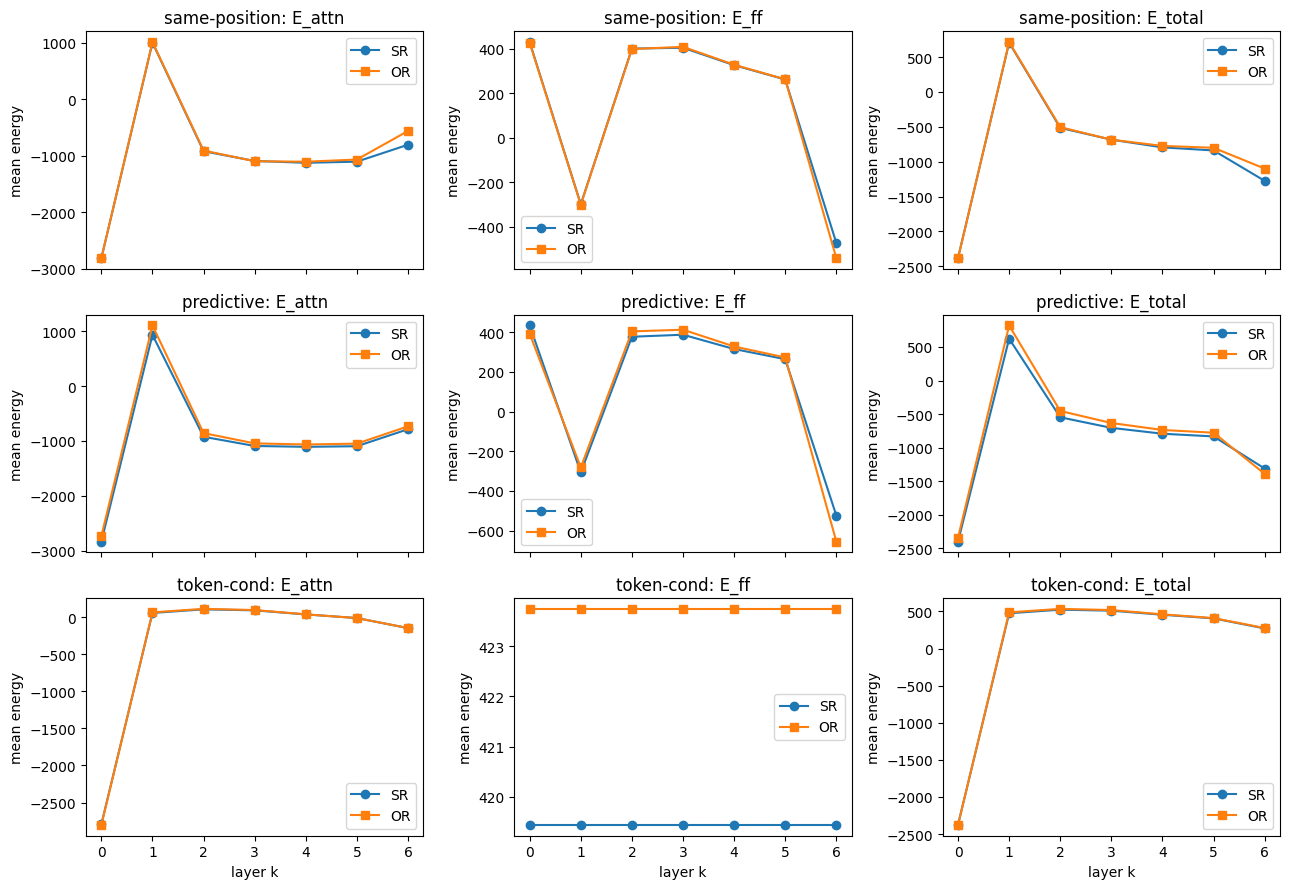

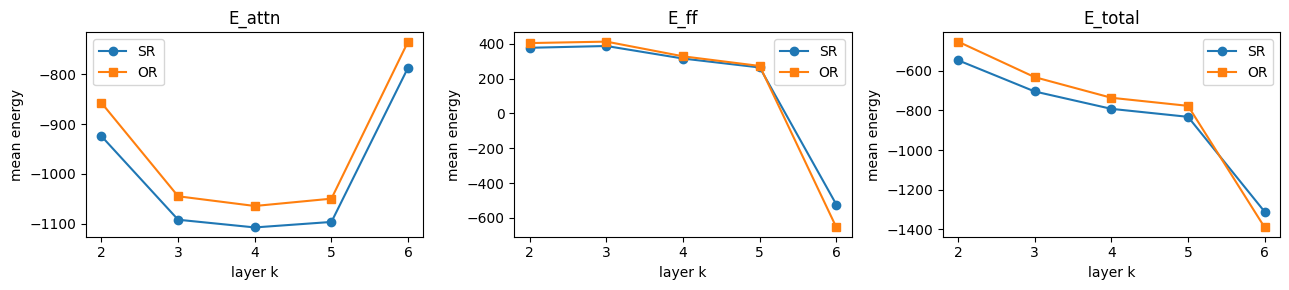

In [66]:
import matplotlib.pyplot as plt

# Three energy "versions" use different column-name templates from nrgpt_analysis.
# pred / token use the single-slot variants (== _sum on single-BPE critical words).
versions = [
    ("same-position", "E_{c}_{k}"),
    ("predictive",    "E_{c}_pred_{k}"),
    ("token-cond",    "E_{c}_token_{k}"),
]
components = ["attn", "ff", "total"]
layers = list(range(7))

fig, axes = plt.subplots(len(versions), len(components),
                         figsize=(13, 9), sharex=True)

for r, (label, fmt) in enumerate(versions):
    for c, comp in enumerate(components):
        ax = axes[r, c]
        for cond, marker in [("SR", "o"), ("OR", "s")]:
            means = [results_df.loc[results_df["type"] == cond,
                                    fmt.format(c=comp, k=k)].mean()
                     for k in layers]
            ax.plot(layers, means, marker=marker, label=cond)
        ax.set_title(f"{label}: E_{comp}")
        ax.set_ylabel("mean energy")
        ax.legend()
        if r == len(versions) - 1:
            ax.set_xlabel("layer k")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, len(components),
                         figsize=(13, 3), sharex=True)

layers = list(range(2, 7))

for c, comp in enumerate(components):
        ax = axes[c]
        for cond, marker in [("SR", "o"), ("OR", "s")]:
            means = [results_df.loc[results_df["type"] == cond,
                                    "E_{c}_pred_{k}".format(c=comp, k=k)].mean()
                     for k in layers]
            ax.plot(layers, means, marker=marker, label=cond)
        ax.set_title(f"E_{comp}")
        ax.set_ylabel("mean energy")
        ax.legend()
        if r == len(versions) - 1:
            ax.set_xlabel("layer k")

plt.tight_layout()
plt.savefig('energy_verb.png', bbox_inches='tight')
plt.show()

In [11]:
import numpy as np

metrics = [
    ("surprisal",        "surprisal"),
    ("E_total L0",       "E_total_0"),
    ("E_total L5",       "E_total_5"),
    ("E_total L6",       "E_total_6"),
    ("E_total_pred L0",  "E_total_pred_0"),
    ("E_total_pred L5",  "E_total_pred_5"),
    ("E_attn_pred L5",  "E_attn_pred_5"),
    ("E_ff_pred L5",  "E_ff_pred_5"),
    ("expected_score_pred_5",  "expected_score_pred_5"),
    ("entropy_pred_5",  "entropy_pred_5"),
    ("E_total_pred L6",  "E_total_pred_6"),
    ("E_total_token L0", "E_total_token_0"),
    ("E_total_token L5", "E_total_token_5"),
    ("E_total_token L6", "E_total_token_6"),
]

pivot = results_df.pivot(index="id", columns="type")

stats = []
for name, col in metrics:
    diffs = pivot[(col, "OR")] - pivot[(col, "SR")]
    n = diffs.count()
    m = diffs.mean()
    s = diffs.std(ddof=1)
    t = m / (s / np.sqrt(n))
    stats.append({"metric": name, "mean(OR-SR)": m, "std": s, "t": t, "n": n})

diff_df = pd.DataFrame(stats)
diff_df

,metric,mean(OR-SR),std,t,n
0,surprisal,0.037466,1.680208,0.109240,24
1,E_total L0,-3.726308,5.140544,-3.551201,24
2,E_total L5,38.205121,19.425017,9.635313,24
3,E_total L6,175.498978,141.117660,6.092546,24
4,E_total_pred L0,58.363556,236.606672,1.208427,24
5,E_total_pred L5,55.331159,17.668521,15.341760,24
6,E_attn_pred L5,46.702749,25.818899,8.861563,24
7,E_ff_pred L5,8.628402,15.751609,2.683559,24
8,expected_score_pred_5,-50.578061,26.487624,-9.354591,24
9,entropy_pred_5,3.875317,1.484461,12.789221,24


In [12]:
# Embedded NP onset: 'the' of 'the [obj]' in SR vs OR (Staub2010 SRC-control file).
# - SR: "... who VERB the kids ..."  -> 'the' right after the verb
# - OR: "... who the kids VERB ..."  -> 'the' right after the rel pronoun
# Same lexical item AND same absolute position (the file's 'afternoon' lead-in pads OR
# so 'the' lands at the same word index as SR). What differs is the preceding role:
# verb -> the (SR) vs rel-pronoun -> the (OR).

df_src = pd.read_csv("psych_data/memory-for-prediction/psycholinguistic-phenomena/data/Staub2010_loc_control_src.csv")
print(f"{len(df_src)} rows, types: {df_src['type'].value_counts().to_dict()}")

def find_word_range(input_ids, target):
    """Token (start, end) for `target` inside `input_ids`. Tries leading-space form first."""
    for prefix in (" ", ""):
        tgt = tokenizer.encode(prefix + target, add_special_tokens=False)
        if not tgt:
            continue
        for i in range(len(input_ids) - len(tgt) + 1):
            if input_ids[i:i + len(tgt)] == tgt:
                return i, i + len(tgt)
    return None

def find_word_range_after(input_ids, target, start_pos):
    """Same as find_word_range, but only searches starting at `start_pos`."""
    for prefix in (" ", ""):
        tgt = tokenizer.encode(prefix + target, add_special_tokens=False)
        if not tgt:
            continue
        for i in range(start_pos, len(input_ids) - len(tgt) + 1):
            if input_ids[i:i + len(tgt)] == tgt:
                return i, i + len(tgt)
    return None


def find_embedded_the(sentence, type_, crit_verb):
    ids = tokenizer.encode(sentence, return_tensors="pt")[0].tolist()
    rp_span = find_word_range(ids, "who") or find_word_range(ids, "that")
    if rp_span is None:
        return ids, None
    if type_ == "SR":
        v_span = find_word_range_after(ids, crit_verb, rp_span[1])
        if v_span is None:
            return ids, None
        start = v_span[1]
    else:  # OR
        start = rp_span[1]
    return ids, find_word_range_after(ids, "the", start)

48 rows, types: {'SR': 24, 'OR': 24}


In [13]:
def bpe_pos_to_word_idx(words, bpe_pos):
    """Word index in `words` whose word-by-word BPE range contains `bpe_pos`."""
    cum = 0
    for i, w in enumerate(words):
        prefix = "" if i == 0 else " "
        n = len(tokenizer.encode(prefix + w, add_special_tokens=False))
        if cum <= bpe_pos < cum + n:
            return i
        cum += n
    return None


rows_src = []
for _, r in df_src.iterrows():
    ids, the_span = find_embedded_the(r["sentence"], r["type"], r["crit"])
    if the_span is None:
        print(f"  miss embedded 'the': id={r['id']} type={r['type']}")
        continue

    words = r["sentence"].split()
    i = bpe_pos_to_word_idx(words, the_span[0])
    if i is None:
        print(f"  bpe->word fail: id={r['id']} type={r['type']} bpe={the_span}")
        continue

    e_rec, _    = per_word_energies(words, ctx)
    pred_rec, _ = per_word_predictive_energies(words, ctx)
    tok_rec, _  = per_word_predictive_conditional_energies(words, ctx)
    surps, _    = per_word_surprisal(words, ctx)

    rows_src.append({
        "id": r["id"], "type": r["type"], "crit": r["crit"],
        "the_bpe_start": the_span[0],
        **e_rec[i], **pred_rec[i], **tok_rec[i],
        "surprisal": surps[i],
    })

results_src_df = pd.DataFrame(rows_src)
print(results_src_df.shape)
results_src_df.head()

(48, 141)


,id,type,crit,the_bpe_start,word,n_bpe,start,E_attn_0,E_ff_0,E_total_0,...,E_attn_token_sum_5,E_ff_token_sum_5,E_total_token_sum_5,E_attn_token_6,E_ff_token_6,E_total_token_6,E_attn_token_sum_6,E_ff_token_sum_6,E_total_token_sum_6,surprisal
0,1,SR,followed,8,the,1,8,-2499.934570,349.077118,-2150.857422,...,-2108.25753,341.295074,-1766.962456,-2143.075676,341.295074,-1801.780602,-2143.075676,341.295074,-1801.780602,1.718356
1,1,OR,followed,8,the,1,8,-2498.042725,349.077118,-2148.965576,...,-2108.25753,341.295074,-1766.962456,-2143.075676,341.295074,-1801.780602,-2143.075676,341.295074,-1801.780602,7.164137
2,2,SR,distracted,7,the,1,7,-2482.051025,341.295044,-2140.755859,...,-2122.83287,353.879669,-1768.953201,-2150.674362,353.879669,-1796.794693,-2150.674362,353.879669,-1796.794693,1.596973
3,2,OR,distracted,7,the,1,7,-2482.023438,341.295044,-2140.728516,...,-2122.83287,353.879669,-1768.953201,-2150.674362,353.879669,-1796.794693,-2150.674362,353.879669,-1796.794693,6.392719
4,3,SR,woke,7,the,1,7,-2482.051025,341.295044,-2140.755859,...,-2122.83287,353.879669,-1768.953201,-2150.674362,353.879669,-1796.794693,-2150.674362,353.879669,-1796.794693,4.990966


In [15]:
metrics = [
    ("surprisal",        "surprisal"),
    ("E_total L0",       "E_total_0"),
    ("E_total L5",       "E_total_5"),
    ("E_total L6",       "E_total_6"),
    ("E_total_pred L0",  "E_total_pred_0"),
    ("E_total_pred L5",  "E_total_pred_5"),
    ("E_attn_pred L5",  "E_attn_pred_5"),
    ("E_ff_pred L5",  "E_ff_pred_5"),
    ("expected_score_pred_5",  "expected_score_pred_5"),
    ("entropy_pred_5",  "entropy_pred_5"),
    ("E_total_pred L6",  "E_total_pred_6"),
    ("E_total_token L0", "E_total_token_0"),
    ("E_total_token L5", "E_total_token_5"),
    ("E_total_token L6", "E_total_token_6"),
]

pivot = results_src_df.pivot(index="id", columns="type")

stats = []
for name, col in metrics:
    diffs = pivot[(col, "OR")] - pivot[(col, "SR")]
    n = diffs.count()
    m = diffs.mean()
    s = diffs.std(ddof=1)
    t = m / (s / np.sqrt(n))
    stats.append({"metric": name, "mean(OR-SR)": m, "std": s, "t": t, "n": n})

diff_src_df = pd.DataFrame(stats)
diff_src_df

,metric,mean(OR-SR),std,t,n
0,surprisal,4.483163,1.393141,15.765039,24
1,E_total L0,0.489502,2.364373,1.014248,24
2,E_total L5,-5.343740,9.414233,-2.780776,24
3,E_total L6,-70.798564,130.807858,-2.651528,24
4,E_total_pred L0,-19.909587,178.358129,-0.546858,24
5,E_total_pred L5,16.698354,17.538383,4.664335,24
6,E_attn_pred L5,15.557821,26.550459,2.870664,24
7,E_ff_pred L5,1.140526,13.415885,0.416477,24
8,expected_score_pred_5,-15.492544,26.751135,-2.837175,24
9,entropy_pred_5,-0.065260,1.221027,-0.261833,24


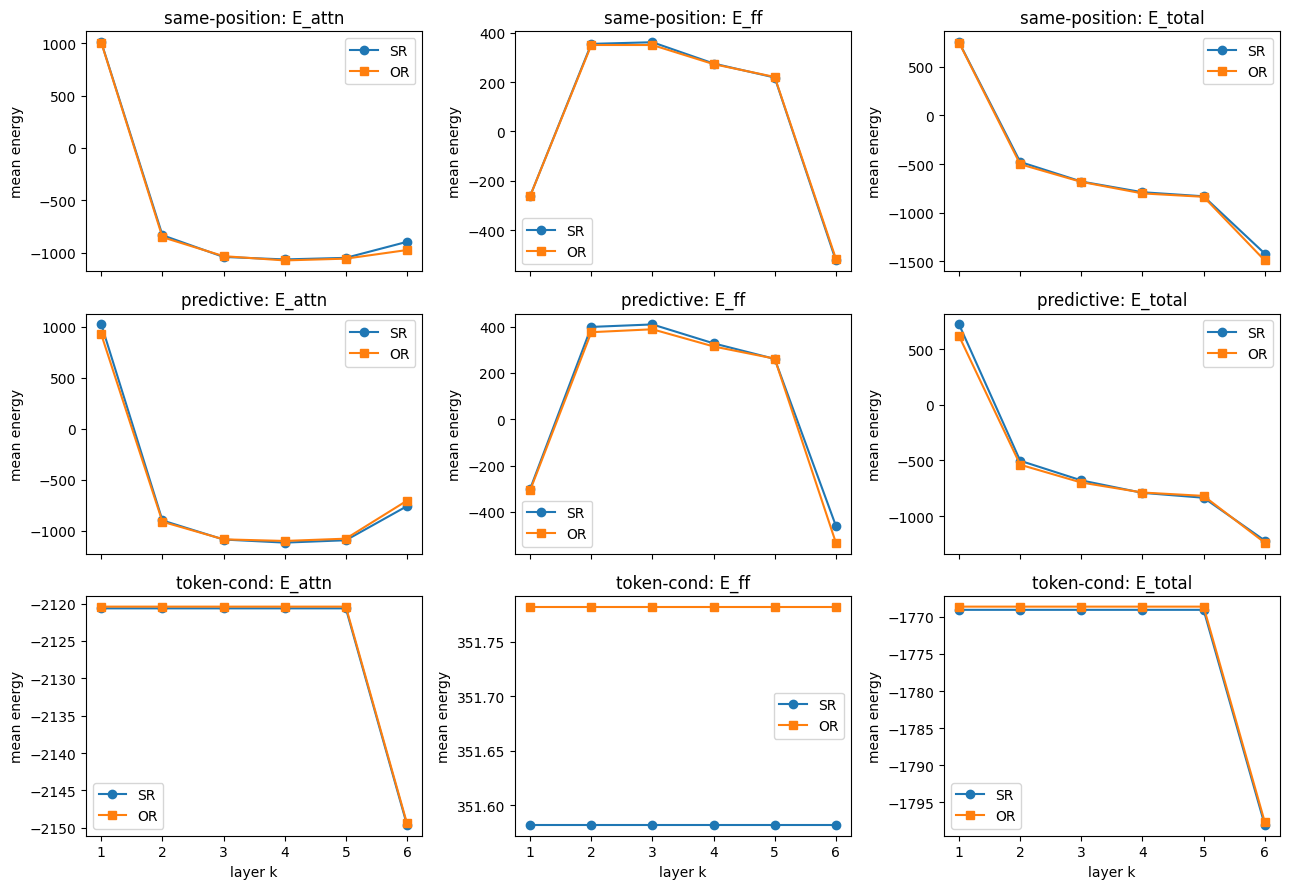

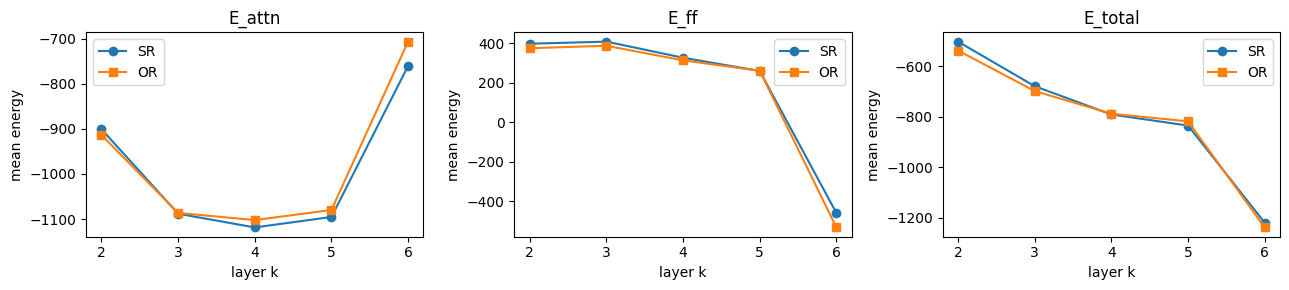

In [65]:
import matplotlib.pyplot as plt

# Three energy "versions" use different column-name templates from nrgpt_analysis.
# pred / token use the single-slot variants (== _sum on single-BPE critical words).
versions = [
    ("same-position", "E_{c}_{k}"),
    ("predictive",    "E_{c}_pred_{k}"),
    ("token-cond",    "E_{c}_token_{k}"),
]
components = ["attn", "ff", "total"]
layers = list(range(1, 7))

fig, axes = plt.subplots(len(versions), len(components),
                         figsize=(13, 9), sharex=True)

for r, (label, fmt) in enumerate(versions):
    for c, comp in enumerate(components):
        ax = axes[r, c]
        for cond, marker in [("SR", "o"), ("OR", "s")]:
            means = [results_src_df.loc[results_src_df["type"] == cond,
                                    fmt.format(c=comp, k=k)].mean()
                     for k in layers]
            ax.plot(layers, means, marker=marker, label=cond)
        ax.set_title(f"{label}: E_{comp}")
        ax.set_ylabel("mean energy")
        ax.legend()
        if r == len(versions) - 1:
            ax.set_xlabel("layer k")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(components),
                         figsize=(13, 3), sharex=True)

layers = list(range(2, 7))

for c, comp in enumerate(components):
        ax = axes[c]
        for cond, marker in [("SR", "o"), ("OR", "s")]:
            means = [results_src_df.loc[results_src_df["type"] == cond,
                                    "E_{c}_pred_{k}".format(c=comp, k=k)].mean()
                     for k in layers]
            ax.plot(layers, means, marker=marker, label=cond)
        ax.set_title(f"E_{comp}")
        ax.set_ylabel("mean energy")
        ax.legend()
        if r == len(versions) - 1:
            ax.set_xlabel("layer k")

plt.tight_layout()
plt.savefig('energy_the.png', bbox_inches='tight')
plt.show()

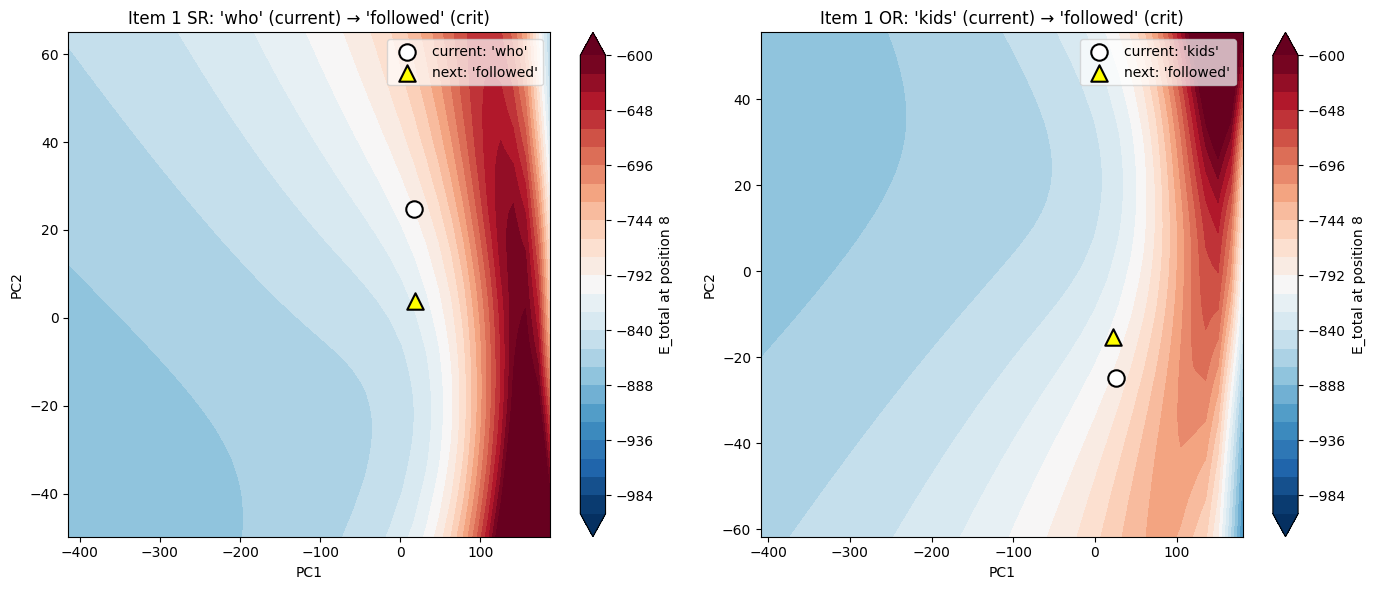

In [9]:
from nrgpt_analysis import plot_energy_landscape_pca

item_id = 1
vmin, vmax = -1000, -600  # fix colour scale across SR and OR panels

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cond in zip(axes, ["SR", "OR"]):
    row = df[(df["id"] == item_id) & (df["type"] == cond)].iloc[0]
    words = row["sentence"].split()
    crit = row["crit"]
    crit_idx = next(i for i, w in enumerate(words) if w.rstrip(",.!?;:") == crit)

    plot_energy_landscape_pca(words, ctx, word_idx=crit_idx - 1, layer=5,
                              vmin=vmin, vmax=vmax, ax=ax)
    ax.set_title(f"Item {item_id} {cond}: '{words[crit_idx - 1]}' (current) → '{crit}' (crit)")

plt.tight_layout()
plt.show()